# Noise sweep (stride_x=stride_t=2)

Sweeps `noise ? {0, 0.05, 0.1, 0.5, 0.7}` under fixed controls.

**Controls**
- `stride_x = 2`, `stride_t = 2`
- `nu=0.02`
- `steps=8000`, `batch_size=1000`, `lr=0.001`
- `lam_pde=0.5`, `lam_data=10`, `lam_reg=0`

**Dependents (same table outputs)**
- Final `loss_data`, `loss_pde`
- `w_u`, `w_ux`, `w_uxx`, `w_prod` from `eql.readout.weight`
- `M01`, `M10` from `eql.effective_quadratic_matrix(symmetrize=False)`


In [1]:
import sys

sys.path.append('..')  # add project root

import numpy as np
import torch
import matplotlib.pyplot as plt

from prog import mlps, featlib, trainer, hlprs
import Datasets.matconv as mc

SEED = 1432
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cpu')


In [2]:
# Controls

steps = 8000
log_every = 1000

nu = 0.02

stride_x = 2
stride_t = 2

lr = 1e-3
batch_size = 1000

lam_pde = 0.5
lam_data = 10.0
lam_reg = 0.0
lam_tv = 0.0

selected_derivs = ('u','u_x','u_xx')

noise_values = [0.0, 0.05, 0.1, 0.5, 0.7]

# Dataset partitioning controls
part_num = 1
which_part = 1


In [3]:
def run_once(noise: float):
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    partitions = mc.build_dataset_from_burgers(
        noise_level=noise,
        nu=nu,
        stride_t=stride_t,
        stride_x=stride_x,
        seed=SEED,
        quantile_splits=part_num,
        return_partitions=True,
    )

    key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
    t_np, x_np, y_np, y_noisy_np, _N = partitions[key]

    t_torch       = torch.from_numpy(t_np).to(device)
    x_torch       = torch.from_numpy(x_np).to(device)
    y_clean_torch = torch.from_numpy(y_np).to(device)
    y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

    u_model = mlps.SimpleMLP(n_layers=4, hidden_size=64, act=mlps.Sin)
    symnet  = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, num_layers=1, bias=False)

    train_config = trainer.TrainerConfig(
        lr=lr,
        lambda_pde=lam_pde,
        lambda_reg=lam_reg,
        lambda_tv=lam_tv,
        lambda_data=lam_data,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    train = trainer.PDETrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )

    loss_dat = []
    loss_pde = []

    for i in range(steps):
        t, x, u_noisy, u_clean = hlprs.make_batch(
            batch_size=batch_size,
            t_torch=t_torch,
            x_torch=x_torch,
            y_clean=y_clean_torch,
            y_noisy=y_noisy_torch,
        )
        out = train.step(t=t, x=x, u_noisy=u_noisy, u_clean=u_clean)
        loss_dat.append(out['loss_data'])
        loss_pde.append(out['loss_pde'])

        if log_every and i % log_every == 0:
            print(f"[noise={noise:g}] step {i}: data={out['loss_data']:.6e} pde={out['loss_pde']:.6e}")

    w = symnet.readout.weight.detach().cpu().numpy().reshape(-1)
    M = symnet.effective_quadratic_matrix(symmetrize=False).detach().cpu().numpy()

    return {
        'noise': float(noise),
        'loss_data_final': float(loss_dat[-1]),
        'loss_pde_final': float(loss_pde[-1]),
        'w_u': float(w[0]),
        'w_ux': float(w[1]),
        'w_uxx': float(w[2]),
        'w_prod': float(w[-1]),
        'M01': float(M[0,1]),
        'M10': float(M[1,0]),
        'loss_data_curve': loss_dat,
        'loss_pde_curve': loss_pde,
        'readout_weight': w,
        'M_eff': M,
    }


In [4]:
# Run sweep

results = []
for nz in noise_values:
    print('==============================')
    print('Running noise =', nz)
    print('==============================')
    results.append(run_once(nz))

Running noise = 0.0
[noise=0] step 0: data=3.637510e-01 pde=7.341562e-03
[noise=0] step 1000: data=5.589407e-03 pde=7.827669e-03
[noise=0] step 2000: data=4.168301e-04 pde=3.357295e-03
[noise=0] step 3000: data=1.004864e-04 pde=1.390447e-03
[noise=0] step 4000: data=7.522203e-05 pde=8.746701e-04
[noise=0] step 5000: data=5.602315e-05 pde=4.704914e-04
[noise=0] step 6000: data=2.456643e-05 pde=3.514121e-04
[noise=0] step 7000: data=1.996222e-05 pde=2.613498e-04
Running noise = 0.05
[noise=0.05] step 0: data=3.709568e-01 pde=7.341562e-03
[noise=0.05] step 1000: data=9.005016e-03 pde=7.858007e-03
[noise=0.05] step 2000: data=3.095468e-03 pde=3.865614e-03
[noise=0.05] step 3000: data=3.050575e-03 pde=2.347277e-03
[noise=0.05] step 4000: data=2.847451e-03 pde=1.542751e-03
[noise=0.05] step 5000: data=2.702144e-03 pde=1.001139e-03
[noise=0.05] step 6000: data=2.707731e-03 pde=8.403279e-04
[noise=0.05] step 7000: data=2.620859e-03 pde=6.081087e-04
Running noise = 0.1
[noise=0.1] step 0: data=

In [5]:
# Table output

try:
    import pandas as pd
except ImportError:
    pd = None

cols = [
    'noise',
    'loss_data_final','loss_pde_final',
    'w_u','w_ux','w_uxx','w_prod',
    'M01','M10'
]

rows = [{k: r[k] for k in cols} for r in results]

if pd is not None:
    df = pd.DataFrame(rows).sort_values(['noise']).reset_index(drop=True)
    display(df)
    print('Markdown table (paste into email):')
    print(df.to_markdown(index=False))
else:
    print(rows)


,noise,loss_data_final,loss_pde_final,w_u,w_ux,w_uxx,w_prod,M01,M10
0,0.00,0.000018,0.000226,0.005766,0.208256,0.011614,-0.838292,-0.999875,0.000011
1,0.05,0.002618,0.000518,0.049442,0.210222,0.011069,-0.830863,-0.999936,-0.000032
2,0.10,0.010536,0.000637,0.084303,0.213798,0.010586,-0.826228,-1.005145,-0.000158
3,0.50,0.257749,0.006370,0.250963,0.280957,0.004482,-0.808496,-0.988323,-0.003681
4,0.70,0.506281,0.007195,0.297471,0.314578,0.007781,-0.800498,-0.976920,-0.005898


Markdown table (paste into email):
|   noise |   loss_data_final |   loss_pde_final |        w_u |     w_ux |      w_uxx |    w_prod |       M01 |          M10 |
|--------:|------------------:|-----------------:|-----------:|---------:|-----------:|----------:|----------:|-------------:|
|    0    |       1.76857e-05 |      0.000226157 | 0.00576631 | 0.208256 | 0.0116137  | -0.838292 | -0.999875 |  1.08749e-05 |
|    0.05 |       0.00261776  |      0.000517769 | 0.0494417  | 0.210222 | 0.0110694  | -0.830863 | -0.999936 | -3.19798e-05 |
|    0.1  |       0.0105357   |      0.000636588 | 0.084303   | 0.213798 | 0.0105858  | -0.826228 | -1.00515  | -0.000158124 |
|    0.5  |       0.257749    |      0.00636991  | 0.250963   | 0.280957 | 0.00448187 | -0.808496 | -0.988323 | -0.00368132  |
|    0.7  |       0.506281    |      0.0071946   | 0.297471   | 0.314578 | 0.00778067 | -0.800498 | -0.97692  | -0.00589764  |


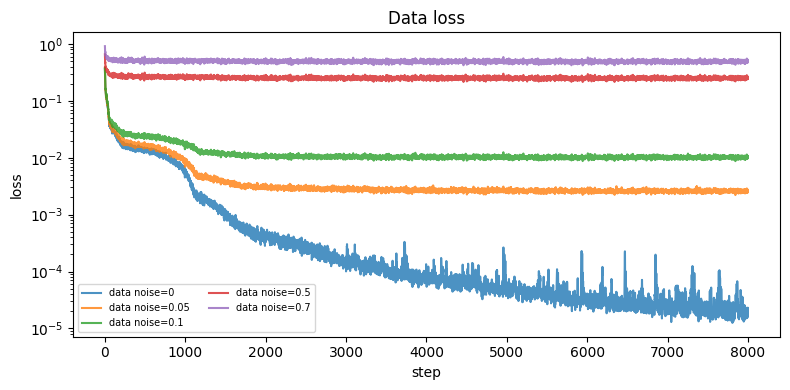

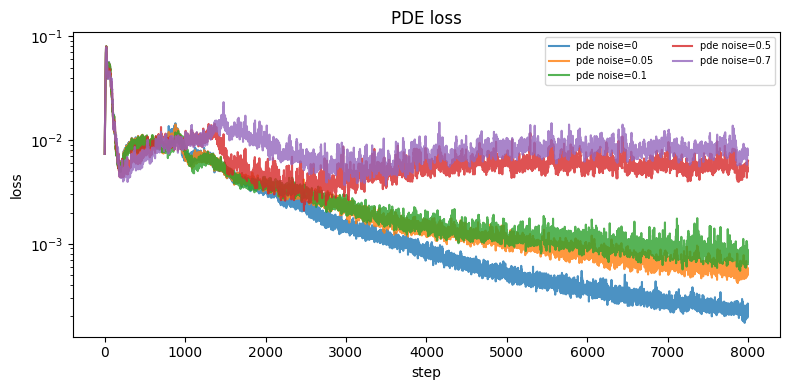

In [6]:
# Plot loss curves (data, pde) per noise

plt.figure(figsize=(8,4))
for r in results:
    plt.plot(r['loss_data_curve'], label=f"data noise={r['noise']:g}", alpha=0.8)
plt.yscale('log'); plt.xlabel('step'); plt.ylabel('loss'); plt.title('Data loss'); plt.legend(fontsize=7, ncols=2); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
for r in results:
    plt.plot(r['loss_pde_curve'], label=f"pde noise={r['noise']:g}", alpha=0.8)
plt.yscale('log'); plt.xlabel('step'); plt.ylabel('loss'); plt.title('PDE loss'); plt.legend(fontsize=7, ncols=2); plt.tight_layout(); plt.show()
